<a href="https://colab.research.google.com/github/thatvivekhingu/Machine_learning/blob/main/07_K_Means_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

In [71]:
df=pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income')

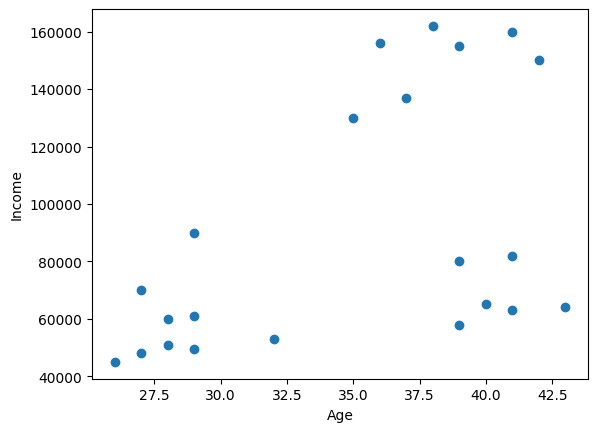

In [8]:
plt.scatter(df.Age,df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')

In [16]:
km =KMeans(n_clusters=3) ## plot se pata chalta hai total 3 cluster hai
y_predicted =km.fit_predict(df[['Age','Income($)']]) ## age and income ko as inpuput leke konse cluster me point pe aa raha hai vo dekhenge
y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [13]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [15]:
km.cluster_centers_  ## cluster ke centers point konse hai vo dikhaye hai x,y positions se

array([[3.24166667e+01, 5.72916667e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.63333333e+01, 8.40000000e+04]])

In [17]:
df0 = df[df.cluster==0]
df1= df[df.cluster==1]
df2=df[df.cluster==2]

/tmp/ipython-input-1895974619.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


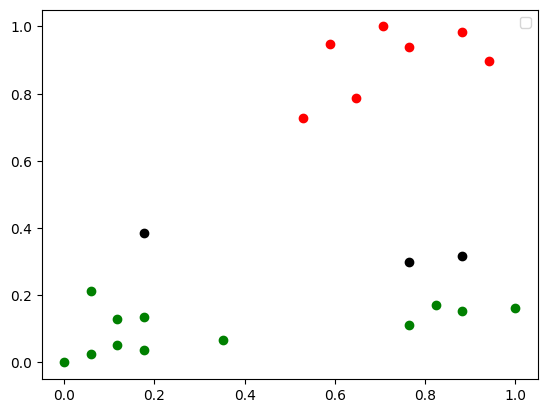

In [72]:
plt.scatter(df0.Age ,df0['Income($)'],color='green')
plt.scatter(df1.Age,df1['Income($)'],color='red')
plt.scatter(df2.Age,df2['Income($)'],color='black')
plt.legend()

In [21]:
# clustering sahi se nahi huva kyuki data set me sequence thodi scaling sahi nahi hai difference jyada hai

In [73]:
scaler = MinMaxScaler()
df[['Age', 'Income($)']] = scaler.fit_transform(df[['Age', 'Income($)']])
df.head()

,Name,Age,Income($)
0,Rob,0.058824,0.213675
1,Michael,0.176471,0.384615
2,Mohan,0.176471,0.136752
3,Ismail,0.117647,0.128205
4,Kory,0.941176,0.897436


In [74]:
km =KMeans(n_clusters=3,random_state=42) ## plot se pata chalta hai total 3 cluster hai
y_predicted =km.fit_predict(df[['Age','Income($)']]) ## age and income ko as inpuput leke konse cluster me point pe aa raha hai vo dekhenge
y_predicted

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [75]:
df['cluster']=y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [76]:
km.cluster_centers_

array([[0.72268908, 0.8974359 ],
       [0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ]])

In [77]:
df0 = df[df.cluster==0]
df1= df[df.cluster==1]
df2=df[df.cluster==2]

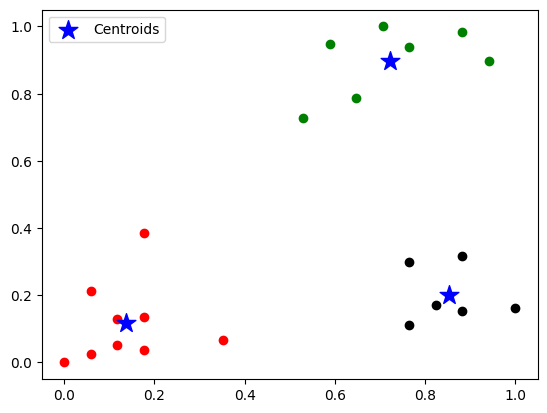

In [78]:
centers = km.cluster_centers_
plt.scatter(df0.Age ,df0['Income($)'], color='green')
plt.scatter(df1.Age, df1['Income($)'], color='red')
plt.scatter(df2.Age, df2['Income($)'], color='black')
plt.scatter(centers[:, 0], centers[:, 1], color='blue', marker='*', s=200, label='Centroids')
plt.legend()
plt.show()


In [82]:
## uisng elbow method to find number of clusters
## and finding sum of squrred error

In [79]:
sse=[]
k_rng=range(1,10)

for k in k_rng:
  km=KMeans(n_clusters=k)
  km.fit(df[['Age','Income($)']])
  sse.append(km.inertia_)

In [80]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553097,
 0.4028477025734001,
 0.36348224386848604,
 0.28198668504542,
 0.2239985473505126,
 0.1768745329494893,
 0.11073569527418643]

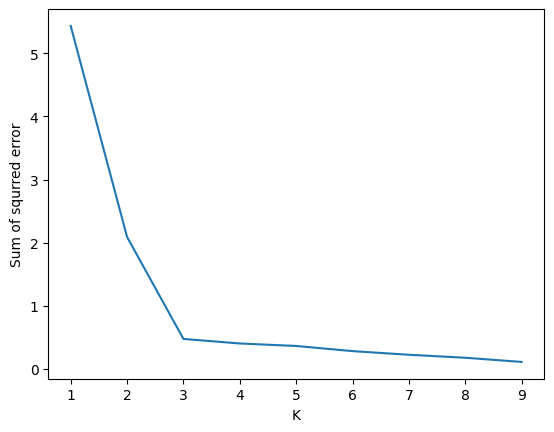

In [81]:
plt.xlabel('K')
plt.ylabel('Sum of squrred error')
plt.plot(k_rng,sse)